In [1]:
import numpy as np
from scipy import fftpack
from matplotlib import pyplot as plt

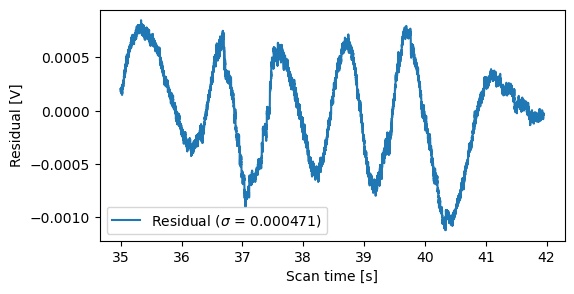

In [2]:
Dataset= np.loadtxt('ResPeak_1.csv', skiprows= 0, delimiter=';')
scan_time = Dataset[:, 0]
sig = Dataset[:, 1]

period = np.max(scan_time)-np.min(scan_time)

time_step = period/len(scan_time)

plt.figure(figsize=(6, 3))
plt.plot(scan_time, sig, label='Residual ($\sigma$ = '+ str(np.round(np.std(sig),6))+')')

plt.xlabel('Scan time [s]')
plt.ylabel('Residual [V]')

plt.legend(loc='best')

0.8635951465952764


[]

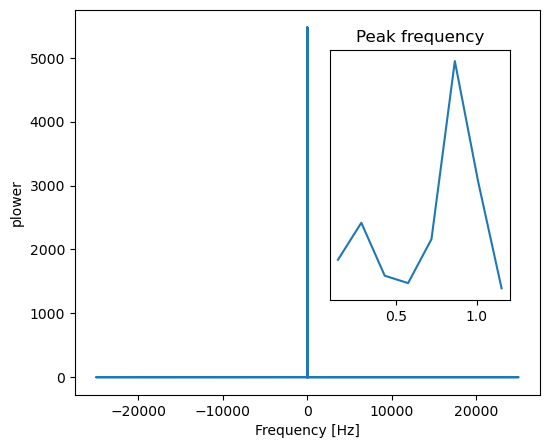

In [3]:
# The FFT of the signal
sig_fft = fftpack.fft(sig)

# And the power (sig_fft is of complex dtype)
power = np.abs(sig_fft)**2

# The corresponding frequencies
sample_freq = fftpack.fftfreq(sig.size, d=time_step)

# Plot the FFT power
plt.figure(figsize=(6, 5))
plt.plot(sample_freq, power)
plt.xlabel('Frequency [Hz]')
plt.ylabel('plower')

# Find the peak frequency: we can focus on only the positive frequencies
pos_mask = np.where(sample_freq > 0)
freqs = sample_freq[pos_mask]
peak_freq = freqs[power[pos_mask].argmax()]

print(peak_freq)

# Check that it does indeed correspond to the frequency that we generate
# the signal with
np.allclose(peak_freq, 1./period)

# An inner plot to show the peak frequency
axes = plt.axes([0.55, 0.3, 0.3, 0.5])
plt.title('Peak frequency')
plt.plot(freqs[:8], power[pos_mask][:8])
plt.setp(axes, yticks=[])

# scipy.signal.find_peaks_cwt can also be used for more advanced
# peak detection

C:\Users\vaclav\miniconda3\envs\hapi\Lib\site-packages\matplotlib\cbook\__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


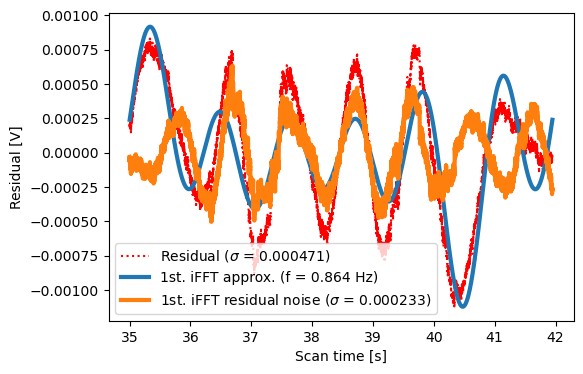

In [4]:
high_freq_fft = sig_fft.copy()
high_freq_fft[np.abs(sample_freq) > peak_freq] = 0
filtered_sig = fftpack.ifft(high_freq_fft)

fftres=sig-filtered_sig

plt.figure(figsize=(6, 5))
plt.plot(scan_time, sig, 'r:',label='Residual ($\sigma$ = '+ str(np.round(np.std(sig),6)) +')')
plt.plot(scan_time, filtered_sig, linewidth=3, label='1st. iFFT approx. (f = '+ str(np.round(peak_freq,3))+' Hz)')
plt.plot(scan_time, fftres, linewidth=3, label='1st. iFFT residual noise ($\sigma$ = '+ str(np.round(np.std(fftres),6))+')')
plt.xlabel('Scan time [s]')
plt.ylabel('Residual [V]')

plt.legend(loc='best')

plt.gcf().set_size_inches(6,4)
plt.savefig("iFFT_1st.pdf", dpi=1000, bbox_inches='tight')



1.0075276710278225


[]

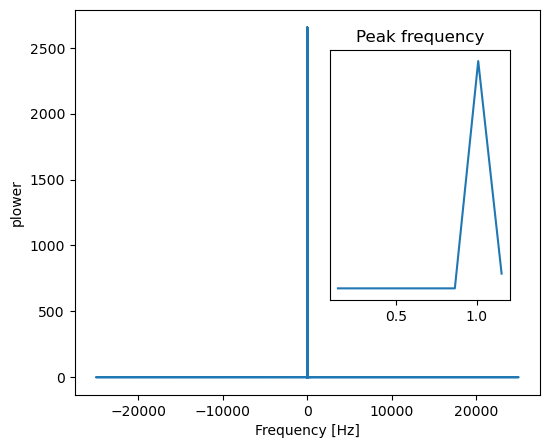

In [5]:
# The FFT of the signal
sig_fft2 = fftpack.fft(fftres)

# And the power (sig_fft is of complex dtype)
power = np.abs(sig_fft2)**2

# The corresponding frequencies
sample_freq2 = fftpack.fftfreq(fftres.size, d=time_step)

# Plot the FFT power
plt.figure(figsize=(6, 5))
plt.plot(sample_freq2, power)
plt.xlabel('Frequency [Hz]')
plt.ylabel('plower')

# Find the peak frequency: we can focus on only the positive frequencies
pos_mask = np.where(sample_freq2 > 0)
freqs2 = sample_freq2[pos_mask]
peak_freq2 = freqs2[power[pos_mask].argmax()]

print(peak_freq2)

# Check that it does indeed correspond to the frequency that we generate
# the signal with
np.allclose(peak_freq2, 1./period)

# An inner plot to show the peak frequency
axes = plt.axes([0.55, 0.3, 0.3, 0.5])
plt.title('Peak frequency')
plt.plot(freqs2[:8], power[pos_mask][:8])
plt.setp(axes, yticks=[])

C:\Users\vaclav\miniconda3\envs\hapi\Lib\site-packages\matplotlib\cbook\__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


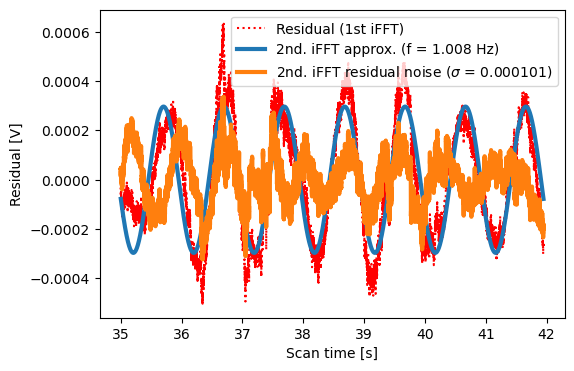

In [6]:
freq_fft2 = sig_fft2.copy()
freq_fft2[np.abs(sample_freq2) > peak_freq2] = 0
#freq_fft2[np.abs(sample_freq2) < peak_freq2] = 0
#freq_fft2[np.abs(sample_freq2) == peak_freq2] = 0

filtered_sig2 = fftpack.ifft(freq_fft2)

fftres2=fftres-filtered_sig2

plt.figure(figsize=(6, 5))
plt.plot(scan_time, fftres, 'r:',label='Residual (1st iFFT)')
plt.plot(scan_time, filtered_sig2, linewidth=3, label='2nd. iFFT approx. (f = ' + str(np.round(peak_freq2,3))+' Hz)')
plt.xlabel('Scan time [s]') 
plt.plot(scan_time, fftres2, linewidth=3, label = '2nd. iFFT residual noise ($\sigma$ = '+ str(np.round(np.std(fftres2),6))+')')
plt.ylabel('Residual [V]')

plt.legend(loc='best')

plt.gcf().set_size_inches(6,4)
plt.savefig("iFFT_2nd.pdf", dpi=1000, bbox_inches='tight')

1.1514601954603685


[]

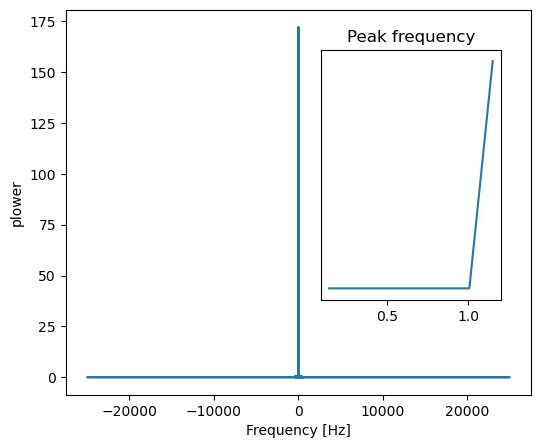

In [7]:
# The FFT of the signal
sig_fft3 = fftpack.fft(fftres2)

# And the power (sig_fft is of complex dtype)
power = np.abs(sig_fft3)**2

# The corresponding frequencies
sample_freq3 = fftpack.fftfreq(fftres2.size, d=time_step)

# Plot the FFT power
plt.figure(figsize=(6, 5))
plt.plot(sample_freq3, power)
plt.xlabel('Frequency [Hz]')
plt.ylabel('plower')

# Find the peak frequency: we can focus on only the positive frequencies
pos_mask = np.where(sample_freq3 > 0)
freqs3 = sample_freq3[pos_mask]
peak_freq3 = freqs3[power[pos_mask].argmax()]

print(peak_freq3)

# Check that it does indeed correspond to the frequency that we generate
# the signal with
np.allclose(peak_freq3, 1./period)

# An inner plot to show the peak frequency
axes = plt.axes([0.55, 0.3, 0.3, 0.5])
plt.title('Peak frequency')
plt.plot(freqs3[:8], power[pos_mask][:8])
plt.setp(axes, yticks=[])

C:\Users\vaclav\miniconda3\envs\hapi\Lib\site-packages\matplotlib\cbook\__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


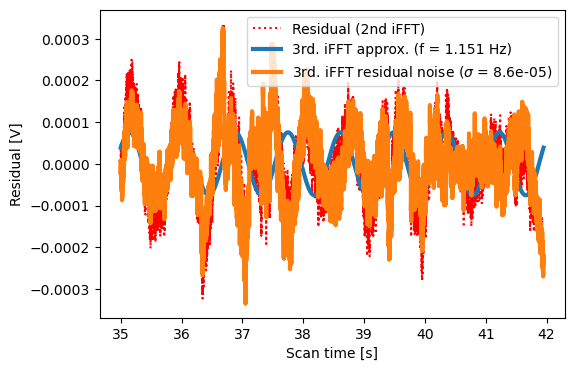

In [8]:
freq_fft3 = sig_fft3.copy()
#freq_fft2[np.abs(sample_freq2) > peak_freq2] = 0
#freq_fft2[np.abs(sample_freq2) < peak_freq2] = 0
freq_fft3[np.abs(sample_freq3) == peak_freq3] = 0

filtered_sig3 = fftpack.ifft(freq_fft3)

fftres3 = fftres2 - filtered_sig3

plt.figure(figsize=(6, 5))
plt.plot(scan_time, fftres2, 'r:',label='Residual (2nd iFFT)')
plt.plot(scan_time, fftres3, linewidth=3, label='3rd. iFFT approx. (f = ' + str(np.round(peak_freq3,3))+' Hz)')
plt.xlabel('Scan time [s]') 
plt.plot(scan_time, filtered_sig3, linewidth=3, label = '3rd. iFFT residual noise ($\sigma$ = '+ str(np.round(np.std(filtered_sig3),6))+')')
plt.ylabel('Residual [V]')

plt.legend(loc='best')

plt.gcf().set_size_inches(6,4)
plt.savefig("iFFT_3rd.pdf", dpi=1000, bbox_inches='tight')